# Mapping Safety, Danger, and Visibility  
## Damron Guides, the New York Times, and the Problem of Perspective in Queer Historical NLP

This project aims to answer that question of whether gay safe places increased between 1965 and 1985, or if they become more visible, more contested, and more unevenly represented depending on who was recording them?

The important aspect of this project is that it doesn't treat computational analysis as a neutral way to get a singular final answer. Instead, it compares two different archives: the Damron Guides, which represents an insider/community mapping of queer spaces, and the New York Times which represents a mainstream/outsider perspective about homosexuality, policing, morality, rights, and public crisis. This project explores an interpretive tool for placing two unequal perspectives side by side and using it to get a useful insight. 

## 1. Project setup

This notebook is designed to run from the raw project files:

- `data.rds`: Damron Guides location dataset
- `nyt_outsider_dataset.csv`: New York Times Archive API dataset

The code below loads, cleans, analyzes, and compares both datasets. The final outputs include annual trend tables, visualizations, and a normalized insider/outsider comparison score.

In [3]:
import os
import re
import sys
import subprocess
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Python executable being used by this notebook:")
print(sys.executable)

Python executable being used by this notebook:
/opt/conda/envs/anaconda-2025.12-py312/bin/python


In [4]:
%pip install pyreadr

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import re
import sys
import subprocess
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyreadr

warnings.filterwarnings("ignore")

DATA_DIR = Path(".")
DAMRON_PATH = DATA_DIR / "data.rds"
NYT_PATH = DATA_DIR / "nyt_outsider_dataset.csv"

# If this notebook is run from a different directory, fall back to /mnt/data.
if not DAMRON_PATH.exists():
    DAMRON_PATH = Path("/mnt/data/data.rds")
if not NYT_PATH.exists():
    NYT_PATH = Path("/mnt/data/nyt_outsider_dataset.csv")

print("Damron file:", DAMRON_PATH)
print("NYT file:", NYT_PATH)
print("Damron exists:", DAMRON_PATH.exists())
print("NYT exists:", NYT_PATH.exists())

Damron file: data.rds
NYT file: nyt_outsider_dataset.csv
Damron exists: True
NYT exists: True


## 2. Load the Damron Guides data

The Damron Guides are the insider/community source. This is not a neutral perspective source. It is biased torwards the viewpoints of people within the LGBTQ community. However, they were very practical guides that helped gay men navigate where they could go, what kinds of places exsisted, and where caution might be necessary. 

For this project, the key Damron measure is the share of cruising locations marked with danger-related codes such as `HOT` or `AYOR`.

In [3]:
# Load RDS file
damron_result = pyreadr.read_r(str(DAMRON_PATH))
damron = next(iter(damron_result.values()))

# Standardize column names lightly while preserving original fields
damron.columns = [str(c).strip() for c in damron.columns]

print("Damron shape:", damron.shape)
display(damron.head())
display(damron.dtypes)

Damron shape: (60698, 13)


,ID,title,description,streetaddress,type,amenityfeatures,city,state,Year,notes,lat,lon,status
0,3213,'B.A.',(woods & ponds),,Cruising Areas,Cruisy Area,Lake Placid,NY,1982,,44.279491,-73.979871,Location could not be verified. General city o...
1,2265,'B.A.' Beach,2 mi. E.,Rte. 2,Cruising Areas,Cruisy Area,Troy,NY,1981,,42.728412,-73.691785,Location could not be verified. General city o...
2,3269,'B.A.' Beach,nr. Salt Air Beach,,Cruising Areas,Cruisy Area,Salt Lake City,UT,1981,,40.747813,-112.187268,Location could not be verified. General city o...
3,3388,'B.A.' Beach,nr. Evergreen Floating Bridge,,Cruising Areas,Cruisy Area,Seattle,WA,1981,,47.606210,-122.332071,Location could not be verified. General city o...
4,3508,'B.A.' Beach,(2 mi. E. on Rte. 2),,Cruising Areas,Cruisy Area,Troy,NY,1982,,42.728412,-73.691785,Location could not be verified. General city o...


ID                   object
title                object
description          object
streetaddress        object
type                 object
amenityfeatures      object
city                 object
state              category
Year                  int32
notes                object
lat                 float64
lon                 float64
status             category
dtype: object

In [6]:
# Basic data checks
required_damron_cols = ["Year", "type", "amenityfeatures"]
missing = [c for c in required_damron_cols if c not in damron.columns]
if missing:
    raise ValueError(f"Missing required Damron columns: {missing}")

damron["Year"] = pd.to_numeric(damron["Year"], errors="coerce").astype("Int64")
damron["type_clean"] = damron["type"].fillna("").astype(str)
damron["amenity_clean"] = damron["amenityfeatures"].fillna("").astype(str)
damron["description_clean"] = damron.get("description", "").fillna("").astype(str) if "description" in damron.columns else ""

# Cruising locations: the Damron dataset includes a type label for Cruising Areas.
damron["is_cruising"] = damron["type_clean"].str.contains("Cruising", case=False, na=False)

# Danger labels: HOT and AYOR are treated as insider danger/caution markers.
danger_label_pattern = r"\b(HOT|AYOR)\b"
damron["damron_danger_label"] = damron["amenity_clean"].str.contains(
    danger_label_pattern, case=False, regex=True, na=False
)

# Optional alternate description-based danger method, useful for showing method sensitivity.
description_danger_terms = [
    "danger", "dangerous", "police", "raid", "raided", "arrest", "arrests",
    "entrapment", "warning", "caution", "risky", "unsafe"
]
description_pattern = "|".join([re.escape(t) for t in description_danger_terms])
damron["description_danger_keyword"] = damron["description_clean"].str.contains(
    description_pattern, case=False, regex=True, na=False
)

print("Total Damron locations:", len(damron))
print("Cruising locations:", int(damron["is_cruising"].sum()))
print("Cruising locations marked HOT/AYOR:", int((damron["is_cruising"] & damron["damron_danger_label"]).sum()))

Total Damron locations: 60698
Cruising locations: 14829
Cruising locations marked HOT/AYOR: 1700


## 3. Damron trend: danger-marked cruising locations by year
This section now utilizes that loaded data to answer the question of whether within the Damron Guides, did the proportion of cruising locations marked with danger/caution labels increase over time? 

The important measure is not only the raw number of dangerous locations. The dataset grows over time, so the more useful measure is the percentage of cruising locations marked HOT/AYOR each year. 

In [7]:
damron_annual = (
    damron.dropna(subset=["Year"])
    .groupby("Year")
    .agg(
        total_locations=("Year", "size"),
        cruising_locations=("is_cruising", "sum"),
        danger_marked_cruising=("damron_danger_label", lambda s: int((s & damron.loc[s.index, "is_cruising"]).sum())),
        description_danger_cruising=("description_danger_keyword", lambda s: int((s & damron.loc[s.index, "is_cruising"]).sum())),
    )
    .reset_index()
)

damron_annual["danger_pct_cruising"] = (
    damron_annual["danger_marked_cruising"] / damron_annual["cruising_locations"] * 100
)
damron_annual["description_danger_pct_cruising"] = (
    damron_annual["description_danger_cruising"] / damron_annual["cruising_locations"] * 100
)

display(damron_annual)

,Year,total_locations,cruising_locations,danger_marked_cruising,description_danger_cruising,danger_pct_cruising,description_danger_pct_cruising
0,1965,785,0,0,0,NaN,NaN
1,1966,867,2,0,0,0.000000,0.000000
2,1968,977,1,0,0,0.000000,0.000000
3,1969,1199,1,0,0,0.000000,0.000000
4,1970,1303,1,0,0,0.000000,0.000000
5,1971,1401,2,0,0,0.000000,0.000000
6,1972,1787,169,1,0,0.591716,0.000000
7,1973,2214,297,1,0,0.336700,0.000000
8,1974,2580,393,5,2,1.272265,0.508906
9,1975,2861,520,30,3,5.769231,0.576923


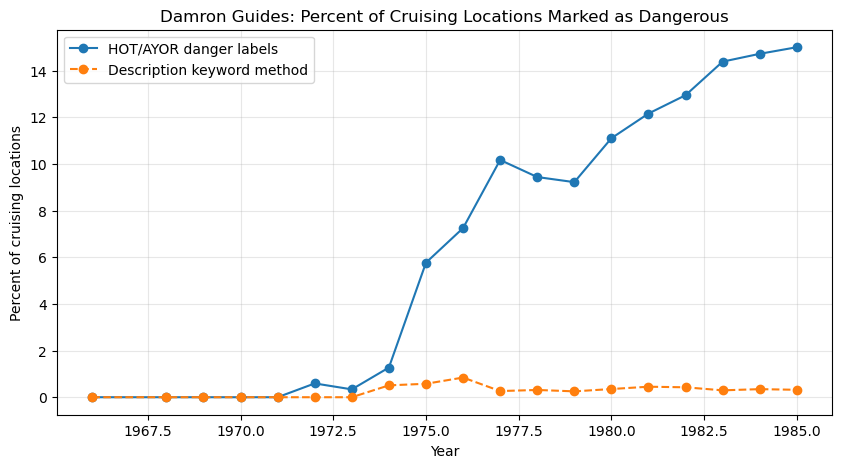

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(damron_annual["Year"], damron_annual["danger_pct_cruising"], marker="o", label="HOT/AYOR danger labels")
plt.plot(damron_annual["Year"], damron_annual["description_danger_pct_cruising"], marker="o", linestyle="--", label="Description keyword method")
plt.title("Damron Guides: Percent of Cruising Locations Marked as Dangerous")
plt.xlabel("Year")
plt.ylabel("Percent of cruising locations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Damron interpretation

The Damron trend should be read as an insider map of navigated risk. A rise in HOT/AYOR markings does not automatically mean that every queer space became more dangerous. It may mean several historically different things at once:

1. Gay cruising locations could be facing more policing or surveillance.
2. Damron may have become more detailed in getting data or create more self-made rules on how to mark locations are danger.
3. Gay men may have had more shared community knowledge about where danger exsists in certain locations
4. Queer spaces may have expanded while also becoming more visible and vulnerable to the outside public. 

This is why the project needs the second source. Damron tells us how danger was mapped from within the community, but it does not tell us how mainstream public discourse framed gay life from the outside.

## 4. How the New York Times outsider dataset was collected

The New York Times outsider dataset, our second dataset, was collected using the New York Times Archive API. This dataset was created to represent an outside or mainstream media perspective on homosexuality, policing, criminilization, public morality, gay rights, public bathrooms, bathouses, and early AIDS-related discourse. 

This source is very different from the Damron Guides as our first source records queer spaces from an insider/community perspective. The New York Times does not directly map gay safe spaces. Instead, it shows how mainstream public discourse noticed, described, criminilzated, or politicized homosexuality and gay public life. The New York Times during this era was more neutral to negative leaning torwards the homosexual community meaning this source provides more context to our argument. 

To collect the dataset, I utilized the NYT monthly archive through the NYT Developer API from the time period of 1965-1985, which is the same time frame as the Damron Guides. For each month, the code downloaded all available article records, filtered out sections that were less relevant to the historical question, searched the article headlines, abstracts, and snippets for selected keywords and saved these matching articles into a newly created nyt_outside_dataset.csv file which is included in this GitHub for public viewing of the created dataset. 

The keywords used were:

```python
DANGER_KEYWORDS = [
    "homosexual", "homosexuality", "homophile",
    "sodomy", "sodomite",
    "morals charge", "morals arrest", "morals case",
    "lewd conduct", "lewd behavior", "lewdness",
    "indecent conduct", "indecent exposure",
    "sexual deviate", "sex deviate", "sexual deviant",
    "sexual psychopath", "sex psychopath",
    "sexual perversion",
    "unnatural act", "unnatural acts",
    "gross indecency", "perverted practices",
    "vice squad", "vice raid", "vice arrest",
    "morals squad",
    "plainclothes arrest", "entrapment",
    "men's room", "public restroom", "public toilet",
    "public lavatory", "comfort station",
    "bathhouse raid", "bathhouse arrest", "gay bathhouse",
    "pervert", "perverts", "degenerate", "degenerates",
    "deviate", "deviates",
    "sodomy law", "sodomy statute", "anti-sodomy",
    "decriminalization",
    "gay bar", "gay rights", "gay liberation",
    "gay activist", "gay protest", "gay march",
    "gay ordinance", "gay discrimination",
    "homosexual rights", "sexual orientation",
    "stonewall",
    "mattachine", "daughters of bilitis",
    "anita bryant", "save our children",
    "gay plague", "gay disease", "gay cancer",
    "acquired immune deficiency",
    "kaposi sarcoma",
    "gay men health crisis"
]
```

The following code documents the collection process. It is included as a Markdown code block rather than an executable cell because it requires a private NYT API key and takes a long time to run. This took approximately 5 hours to run since each API call required around an 8 second delay in order to not hit the per minute limit which was not high at all.

```python
import requests
import re
import time
import pandas as pd

NYT_API_KEY = "YOUR_API_KEY_HERE"

DANGER_KEYWORDS = [
    "homosexual", "homosexuality", "homophile",
    "sodomy", "sodomite",
    "morals charge", "morals arrest", "morals case",
    "lewd conduct", "lewd behavior", "lewdness",
    "indecent conduct", "indecent exposure",
    "sexual deviate", "sex deviate", "sexual deviant",
    "sexual psychopath", "sex psychopath",
    "sexual perversion",
    "unnatural act", "unnatural acts",
    "gross indecency", "perverted practices",
    "vice squad", "vice raid", "vice arrest",
    "morals squad",
    "plainclothes arrest", "entrapment",
    "men's room", "public restroom", "public toilet",
    "public lavatory", "comfort station",
    "bathhouse raid", "bathhouse arrest", "gay bathhouse",
    "pervert", "perverts", "degenerate", "degenerates",
    "deviate", "deviates",
    "sodomy law", "sodomy statute", "anti-sodomy",
    "decriminalization",
    "gay bar", "gay rights", "gay liberation",
    "gay activist", "gay protest", "gay march",
    "gay ordinance", "gay discrimination",
    "homosexual rights", "sexual orientation",
    "stonewall",
    "mattachine", "daughters of bilitis",
    "anita bryant", "save our children",
    "gay plague", "gay disease", "gay cancer",
    "acquired immune deficiency",
    "kaposi sarcoma",
    "gay men health crisis"
]

EXCLUDE_SECTIONS = [
    "arts", "movies", "theater", "television", "books",
    "sports", "food", "travel", "fashion",
    "weather", "crossword"
]

def fetch_month(year, month, api_key, retries=5):
    """Fetch one month of NYT Archive API results, with retry logic for rate limits."""
    url = f"https://api.nytimes.com/svc/archive/v1/{year}/{month}.json"
    params = {"api-key": api_key}

    for attempt in range(retries):
        try:
            response = requests.get(url, params=params, timeout=15)

            if response.status_code == 200:
                return response.json().get("response", {}).get("docs", [])

            elif response.status_code == 429:
                wait = 15 * (attempt + 1)
                print(f"Rate limited on {year}/{month}, waiting {wait}s...")
                time.sleep(wait)

            else:
                print(f"Bad status {response.status_code} for {year}/{month}")
                return []

        except Exception as e:
            print(f"Error {year}/{month}: {e}")
            time.sleep(10)

    print(f"Giving up on {year}/{month} after {retries} attempts")
    return []


def matches_keywords(doc, keywords):
    """
    Return True if a NYT article matches any selected keyword.

    The function searches headline, headline kicker, headline subheading,
    abstract, snippet, and lead paragraph. It also excludes sections that are
    less relevant to the project's historical question.
    """
    section = (doc.get("section_name", "") or "").lower()
    news_desk = (doc.get("news_desk", "") or "").lower()

    if any(ex in section for ex in EXCLUDE_SECTIONS):
        return False

    if any(ex in news_desk for ex in EXCLUDE_SECTIONS):
        return False

    headline = doc.get("headline", {}).get("main", "") or ""
    headline_kicker = doc.get("headline", {}).get("kicker", "") or ""
    headline_sub = doc.get("headline", {}).get("sub", "") or ""
    abstract = doc.get("abstract", "") or ""
    snippet = doc.get("snippet", "") or ""
    lead = doc.get("lead_paragraph", "") or ""

    text = " ".join([
        headline, headline_kicker, headline_sub,
        abstract, snippet, lead
    ]).lower()

    for kw in keywords:
        pattern = r"\b" + re.escape(kw.lower()) + r"\b"
        if re.search(pattern, text):
            return True

    return False


nyt_records = []
yearly_counts = {}

for year in range(1965, 1986):
    year_count = 0

    for month in range(1, 13):
        docs = fetch_month(year, month, NYT_API_KEY)

        for doc in docs:
            if matches_keywords(doc, DANGER_KEYWORDS):
                year_count += 1

                nyt_records.append({
                    "year": year,
                    "month": month,
                    "headline": doc.get("headline", {}).get("main", ""),
                    "abstract": doc.get("abstract", ""),
                    "pub_date": doc.get("pub_date", "")
                })

        time.sleep(6)

    yearly_counts[year] = year_count
    print(f"{year}: {year_count} matching articles")

nyt_df = pd.DataFrame(nyt_records)
nyt_df.to_csv("nyt_outsider_dataset.csv", index=False)

print(f"Done. Total records saved: {len(nyt_df)}")
```

This collection method is very good because it makes the New York Times dataset very transparent and even modifiable. Anybody can go in, add or remove keywords that they determine fit, and create their own new data set(even though it could take quite a while). 

However, it also has some limitations. Since, once again as the theme of this project is, this uses old-school NLP, it is very dependent on the keywords selected. Words such as homosexual, gay rights, or sexual orientation aren't actually danger words in themselves but they were selected to give context on public visibility around gay life. 

Because of this, the NYT dataset shouldn't be used as a direct count of which locations are safe or even if the number of safe gay locations increased. It should be used as context along with other data sets. This just gives a measure of outsider discourse on how mainstream media talked about homosexuality, policing, ect. 

## 5. Load the New York Times outsider dataset

Now, this data set is loaded into the project. Once again, this is our outsider source and is used to give historical context to the time period.

In [10]:
nyt = pd.read_csv(NYT_PATH)

# Basic cleaning
nyt.columns = [str(c).strip() for c in nyt.columns]
required_nyt_cols = ["year", "headline", "abstract"]
missing = [c for c in required_nyt_cols if c not in nyt.columns]
if missing:
    raise ValueError(f"Missing required NYT columns: {missing}")

nyt["year"] = pd.to_numeric(nyt["year"], errors="coerce").astype("Int64")
nyt["headline"] = nyt["headline"].fillna("").astype(str)
nyt["abstract"] = nyt["abstract"].fillna("").astype(str)
nyt["text"] = (nyt["headline"] + " " + nyt["abstract"]).str.lower()

print("NYT shape:", nyt.shape)
print("NYT year range:", int(nyt["year"].min()), "to", int(nyt["year"].max()))
display(nyt.head())

NYT shape: (1966, 6)
NYT year range: 1965 to 1983


,year,month,headline,abstract,pub_date,text
0,1965,1,Chaos on the Docks . . .,The rejection by longshoremen in the Port of N...,1965-01-10T05:00:00+0000,chaos on the docks . . . the rejection by long...
1,1965,1,Hempstead Plans Patrol to Combat Influx of Dev...,"Hempstead, NY, to form special civilian force ...",1965-01-30T05:00:00+0000,hempstead plans patrol to combat influx of dev...
2,1965,1,THERAPY IS FOUND CURING DEVIATES; Psychiatrist...,Dr S B Hadden repts he has successfully treate...,1965-01-31T05:00:00+0000,therapy is found curing deviates; psychiatrist...
3,1965,2,Regents Urge High Court To Declare Film Obscene,Twilight Girls: NYS Appeals Ct reserves decisi...,1965-02-03T05:00:00+0000,regents urge high court to declare film obscen...
4,1965,3,CITY SEEKING END OF JAIL CROWDING; 140 Women P...,"Cavanagh repts 140 prisoners will De shifted, ...",1965-03-20T05:00:00+0000,city seeking end of jail crowding; 140 women p...


## 6. Define NYT keyword categories

Now, instead of using one flat keyword list, this now groups terms into categories. This makes the interpretation stronger because it allows us to differentiate between the different kinds of outside discourse. This is important because the main point of this data set is provide context. This different categories are:

- **Criminalization / policing:** gay life framed through law, vice, arrest, and deviance
- **Public identity / rights:** gay life framed through rights, identity, and political struggle
- **Public health / crisis:** gay life framed through disease, bathhouses, and public panic

These categories, although not perfect still, help our research out a lot. 

In [11]:
keyword_categories = {
    "criminalization_policing": [
        "sodomy", "vice squad", "morals charge", "lewd conduct",
        "sexual deviate", "deviate", "pervert", "entrapment",
        "obscene", "arrest", "raid"
    ],
    "identity_rights": [
        "homosexual", "gay rights", "stonewall", "anita bryant",
        "gay liberation", "lesbian", "gay"
    ],
    "public_health_crisis": [
        "bathhouse", "bathhouse raid", "acquired immune deficiency",
        "aids", "kaposi", "immune deficiency"
    ],
}

def contains_any(text_series, terms):
    pattern = "|".join(re.escape(term.lower()) for term in terms)
    return text_series.str.contains(pattern, case=False, regex=True, na=False)

for category, terms in keyword_categories.items():
    nyt[category] = contains_any(nyt["text"], terms)

nyt["nyt_any_keyword"] = nyt[list(keyword_categories.keys())].any(axis=1)

nyt_category_summary = pd.DataFrame({
    "category": list(keyword_categories.keys()),
    "matching_articles": [int(nyt[c].sum()) for c in keyword_categories.keys()]
})
display(nyt_category_summary)

,category,matching_articles
0,criminalization_policing,459
1,identity_rights,1159
2,public_health_crisis,24


In [12]:
nyt_annual = (
    nyt.dropna(subset=["year"])
    .groupby("year")
    .agg(
        nyt_total_articles=("year", "size"),
        nyt_any_keyword_articles=("nyt_any_keyword", "sum"),
        criminalization_policing_articles=("criminalization_policing", "sum"),
        identity_rights_articles=("identity_rights", "sum"),
        public_health_crisis_articles=("public_health_crisis", "sum"),
    )
    .reset_index()
    .rename(columns={"year": "Year"})
)

# Since the CSV itself was created from targeted keyword searches, the total article count is not all NYT articles.
# This percentage is therefore a within-dataset discourse mix, not a share of all NYT coverage.
nyt_annual["criminalization_share_of_dataset"] = (
    nyt_annual["criminalization_policing_articles"] / nyt_annual["nyt_total_articles"] * 100
)
nyt_annual["identity_rights_share_of_dataset"] = (
    nyt_annual["identity_rights_articles"] / nyt_annual["nyt_total_articles"] * 100
)
nyt_annual["public_health_share_of_dataset"] = (
    nyt_annual["public_health_crisis_articles"] / nyt_annual["nyt_total_articles"] * 100
)

display(nyt_annual)

,Year,nyt_total_articles,nyt_any_keyword_articles,criminalization_policing_articles,identity_rights_articles,public_health_crisis_articles,criminalization_share_of_dataset,identity_rights_share_of_dataset,public_health_share_of_dataset
0,1965,31,26,10,18,1,32.258065,58.064516,3.225806
1,1966,61,51,23,39,1,37.704918,63.934426,1.639344
2,1967,55,44,11,36,0,20.0,65.454545,0.0
3,1968,69,53,13,44,0,18.84058,63.768116,0.0
4,1969,53,48,16,36,0,30.188679,67.924528,0.0
5,1970,77,41,12,30,0,15.584416,38.961039,0.0
6,1971,112,73,23,53,2,20.535714,47.321429,1.785714
7,1972,152,116,41,83,1,26.973684,54.605263,0.657895
8,1973,156,117,60,69,2,38.461538,44.230769,1.282051
9,1974,167,124,35,99,1,20.958084,59.281437,0.598802


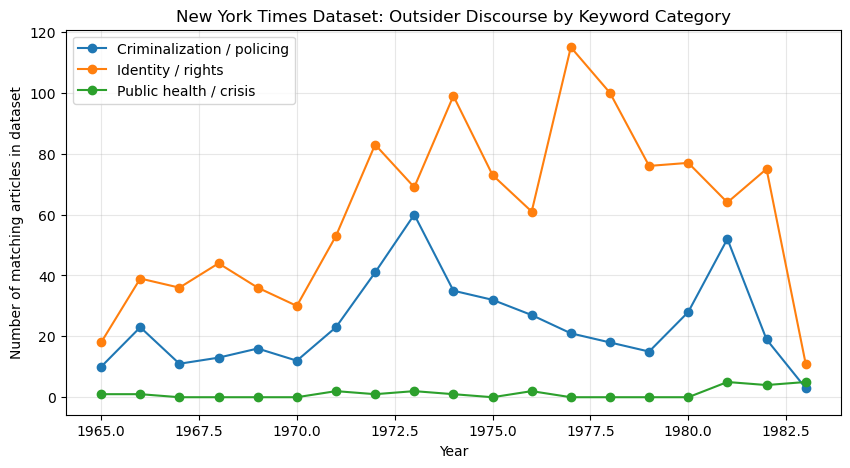

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(nyt_annual["Year"], nyt_annual["criminalization_policing_articles"], marker="o", label="Criminalization / policing")
plt.plot(nyt_annual["Year"], nyt_annual["identity_rights_articles"], marker="o", label="Identity / rights")
plt.plot(nyt_annual["Year"], nyt_annual["public_health_crisis_articles"], marker="o", label="Public health / crisis")
plt.title("New York Times Dataset: Outsider Discourse by Keyword Category")
plt.xlabel("Year")
plt.ylabel("Number of matching articles in dataset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### NYT interpretation

The trends seen above do not measure safety directly. For example, a rise in criminizalition or policing terms doesn't equate to the same increase of danger that Damron would interpret it as. This also shows that mainstream discourse was more likely to encounter gay life through the law, policing, deviance, morality, or crisis. 

This matters a lot because an outsider archive can make gay life visible mainly when it become a public problem. This is very different from the Damron Guides, where gay spaces appear as part of everyday community navigation. 

## 7. Normalized comparison score

These two sources don't measure the same thing. Damron measures places and community danger labels while NYT measures articles and public discourse. This is where one of the major goals of this project come in. Although they don't say the same thing, this is the entire point. Each source contributes a different perspective and including all of this in your analysis, I believe, makes an analysis so much more accurate and better. However, to combine everything into the analysis when they have different scales, I decided to normalize each annual measure from 0 to 1. This puts everything in the same scale and allows us to visually see the trends. 

This combined score is not the objective truth. It is a deliberately transparent interpretive experiment that asks: what happens if insider danger markings and outsider criminalization discourse are weighted equally? Possibly the closest and best way to accurately analyze this question using these data sets. Not only this, besides just answering the question, this is also an exploration of a general framework of analysis that can be used for anyone answering any historical quesiton using old-school NLP, a very helpful tool for parsing through mass amounts of data for trends. This hopefully solves the many issues that plagues old-school NLP such as it's reliance on which perspective the source that its analyzing is from. 

In [14]:
def minmax_normalize(series):
    series = pd.to_numeric(series, errors="coerce")
    min_val = series.min()
    max_val = series.max()
    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.nan, index=series.index)
    return (series - min_val) / (max_val - min_val)

comparison = pd.merge(
    damron_annual[["Year", "cruising_locations", "danger_marked_cruising", "danger_pct_cruising"]],
    nyt_annual[["Year", "nyt_total_articles", "criminalization_policing_articles", "identity_rights_articles", "public_health_crisis_articles"]],
    on="Year",
    how="inner"
)

comparison["damron_insider_danger_norm"] = minmax_normalize(comparison["danger_pct_cruising"])
comparison["nyt_outsider_criminalization_norm"] = minmax_normalize(comparison["criminalization_policing_articles"])

comparison["normalized_comparison_score"] = comparison[
    ["damron_insider_danger_norm", "nyt_outsider_criminalization_norm"]
].mean(axis=1)

comparison["perspective_gap"] = (
    comparison["damron_insider_danger_norm"] - comparison["nyt_outsider_criminalization_norm"]
)

display(comparison)

,Year,cruising_locations,danger_marked_cruising,danger_pct_cruising,nyt_total_articles,criminalization_policing_articles,identity_rights_articles,public_health_crisis_articles,damron_insider_danger_norm,nyt_outsider_criminalization_norm,normalized_comparison_score,perspective_gap
0,1965,0,0,NaN,31,10,18,1,NaN,0.122807,0.122807,NaN
1,1966,2,0,0.000000,61,23,39,1,0.000000,0.350877,0.175439,-0.350877
2,1968,1,0,0.000000,69,13,44,0,0.000000,0.175439,0.087719,-0.175439
3,1969,1,0,0.000000,53,16,36,0,0.000000,0.228070,0.114035,-0.228070
4,1970,1,0,0.000000,77,12,30,0,0.000000,0.157895,0.078947,-0.157895
5,1971,2,0,0.000000,112,23,53,2,0.000000,0.350877,0.175439,-0.350877
6,1972,169,1,0.591716,152,41,83,1,0.041129,0.666667,0.353898,-0.625538
7,1973,297,1,0.336700,156,60,69,2,0.023403,1.000000,0.511702,-0.976597
8,1974,393,5,1.272265,167,35,99,1,0.088433,0.561404,0.324918,-0.472971
9,1975,520,30,5.769231,124,32,73,0,0.401009,0.508772,0.454890,-0.107763


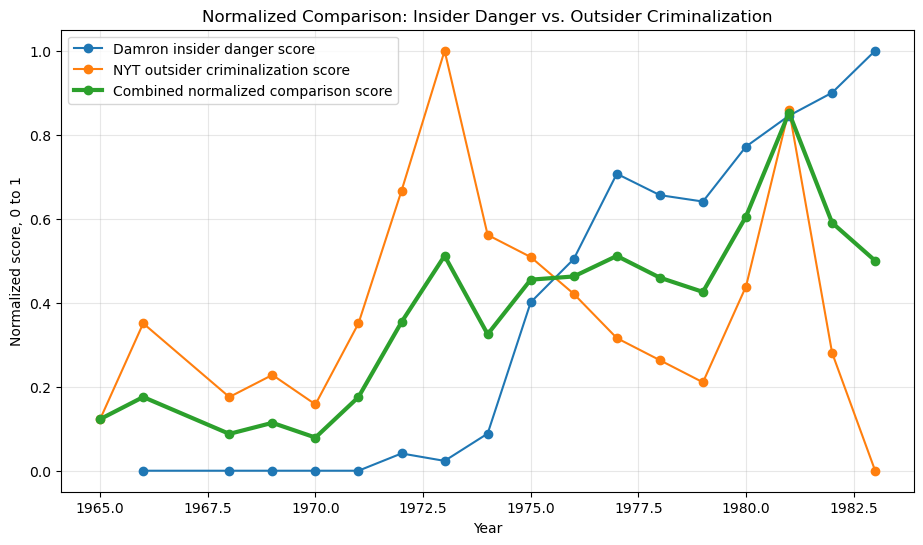

In [15]:
plt.figure(figsize=(11, 6))
plt.plot(comparison["Year"], comparison["damron_insider_danger_norm"], marker="o", label="Damron insider danger score")
plt.plot(comparison["Year"], comparison["nyt_outsider_criminalization_norm"], marker="o", label="NYT outsider criminalization score")
plt.plot(comparison["Year"], comparison["normalized_comparison_score"], marker="o", linewidth=3, label="Combined normalized comparison score")
plt.title("Normalized Comparison: Insider Danger vs. Outsider Criminalization")
plt.xlabel("Year")
plt.ylabel("Normalized score, 0 to 1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

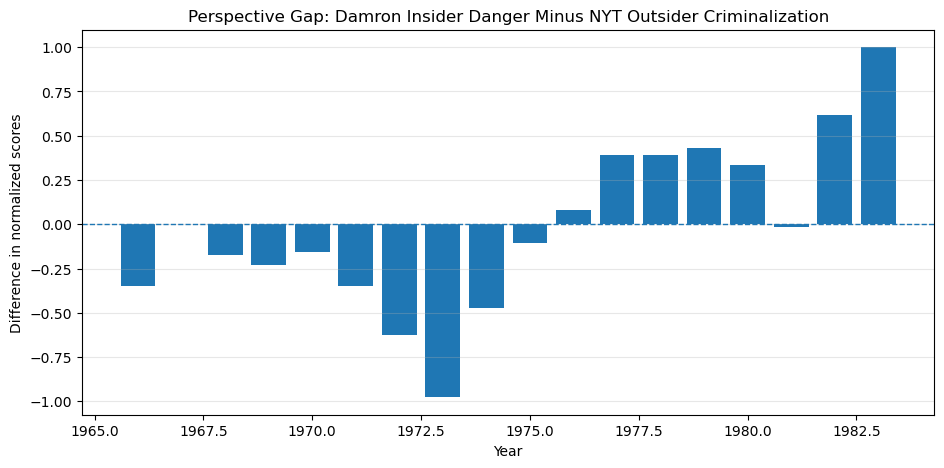

In [16]:
plt.figure(figsize=(11, 5))
plt.axhline(0, linestyle="--", linewidth=1)
plt.bar(comparison["Year"], comparison["perspective_gap"])
plt.title("Perspective Gap: Damron Insider Danger Minus NYT Outsider Criminalization")
plt.xlabel("Year")
plt.ylabel("Difference in normalized scores")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 8. How to read the perspective gap

This perspective gap is one of the most important parts of the project. 

A positive gap in perspective shows that the Damron insider danger score is higher than the NYT outside criminilization score. This suggests that community-mapped danger was more visible inside the guide than in mainstream discourse. 

A negative gap means that the NYT outsider criminilization score is higher than the Damron danger score. This suggests that public discourse may have been emphasizing crime, deviance, policing, or crisis more strongly than the guide's place-based danger labels. 

This, once again, is not a final proof/final answer of what exactly queer life was, but it does show that the historical answer changes depending on whether the source is written from inside or outside the community. 

## 9. Period comparison: 1965–1975 vs. 1976–1985

In my original MVP, I compared earlier and later periods. This final version keeps that same structure, but adds the NYT outsider source and the normalized comparison score. 

However, since the NYT dataset currently runs through 1983, the combined comparison only uses overlapping years between the two datasets. 

In [17]:
def assign_period(year):
    if 1965 <= year <= 1975:
        return "1965-1975"
    elif 1976 <= year <= 1985:
        return "1976-1985"
    return "Outside range"

damron_annual["period"] = damron_annual["Year"].apply(assign_period)
comparison["period"] = comparison["Year"].apply(assign_period)

damron_period_summary = (
    damron_annual[damron_annual["period"] != "Outside range"]
    .groupby("period")
    .agg(
        total_cruising_locations=("cruising_locations", "sum"),
        total_danger_marked_cruising=("danger_marked_cruising", "sum"),
        mean_annual_danger_pct=("danger_pct_cruising", "mean"),
    )
    .reset_index()
)

comparison_period_summary = (
    comparison[comparison["period"] != "Outside range"]
    .groupby("period")
    .agg(
        mean_damron_insider_danger_norm=("damron_insider_danger_norm", "mean"),
        mean_nyt_outsider_criminalization_norm=("nyt_outsider_criminalization_norm", "mean"),
        mean_normalized_comparison_score=("normalized_comparison_score", "mean"),
        mean_perspective_gap=("perspective_gap", "mean"),
    )
    .reset_index()
)

display(damron_period_summary)
display(comparison_period_summary)

,period,total_cruising_locations,total_danger_marked_cruising,mean_annual_danger_pct
0,1965-1975,1386,37,0.885546
1,1976-1985,13443,1663,11.641203


,period,mean_damron_insider_danger_norm,mean_nyt_outsider_criminalization_norm,mean_normalized_comparison_score,mean_perspective_gap
0,1965-1975,0.061553,0.412281,0.239979,-0.382892
1,1976-1985,0.753155,0.348684,0.550920,0.404471


In [18]:
# Export final tables for reproducibility
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

damron_annual.to_csv(output_dir / "damron_annual_trends.csv", index=False)
nyt_annual.to_csv(output_dir / "nyt_annual_trends.csv", index=False)
comparison.to_csv(output_dir / "normalized_comparison_score.csv", index=False)

print("Saved:")
print(output_dir / "damron_annual_trends.csv")
print(output_dir / "nyt_annual_trends.csv")
print(output_dir / "normalized_comparison_score.csv")

Saved:
outputs/damron_annual_trends.csv
outputs/nyt_annual_trends.csv
outputs/normalized_comparison_score.csv


## 10. Final historical interpretation

Although I started off this project to answer the question "did gay safe places increase?", progressing through the project and finding new analysis methods have made me realize that this is too simple of a question on its own. The Damron Guides indicates that queer spaces, especially cruising locations, were being mapped in increasingly detailed ways. Some were also marked with danger/caution labels such as HOT and AYOR. That suggests not just danger, but community knowledge about how to move through danger. 

The New York Times data attained through the NYT Developer API tells a different story. As an outsider archive, it does not map queer spaces from the perspective of gay men using those spaces. It records how mainstream media made homosexuality visible through public categories such as deviance, law, rights, morality, policing, and crisis. 

The normalized comparison score shows that these two perspectives can be placed side by side, but not collased into a single netural answer. When the two scores move together, it suggests moments when community danger and public discourse intensified at the same time. When they diverge, it shows that one archive was registering something the other was not. 

The strongest conclusion is therefore not simply that gay safe spaces increased or decreased. Instead, queer spaces became more visible, more documented, and more contested between 1965 and 1985. Damron shows the insider geography of navigation and risk. The New York Times shows the outsider language of public recognition and control. NLP is useful because it can expose these large-scale patterns, but it is dangerous if treated as objective. The algorithm basically amplifies the archive's perspective. 

## 10. Methodological and ethical limits

This project has several important limits:

1. Keyword dependance: The results depend on selected terms. Different terms would produce different counts.

2. Source perspectives: Damron and NYT are both not neutral archives. They represent different audiences, purposes, and power relationships. In our analysis, this is very helpful and actually an integral part of our final conclusion, but it is also a very limiting factor in the sense of trying to include every perspective in the analysis set.

3. Coded language: Queer history often appears through coded or stigmatizing language. Searching only modern terms would miss much of the archive.

4. False positives: Some NYT articles may include keywords in contexts unrelated to gay spaces or queer community life.

5. False negatives: Some relevant articles or Damron entries may not contain the chosen keywords.

6. Different units of analysis: Damron entries are locations. NYT rows are articles. The normalized comparison score makes them visually comparable, but it does not make them the same kind of evidence. Making them numerically comparable would be the next challenge to be conquered if I further continue this project past this class. 

For these reasons, the final method is best understood as triangulation, not correction. This project does not remove bias. It makes bias visible and historically meaningful. 